In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import AxesImage
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from sklearn.base import BaseEstimator, RegressorMixin
from typing import TypeAlias

In [2]:
type Array = np.ndarray

In [3]:
N = 500
X = np.linspace(start=0, stop=1, num=N)
e = np.random.normal(loc=0, scale=0.3, size=N)

y = 3 * X + e

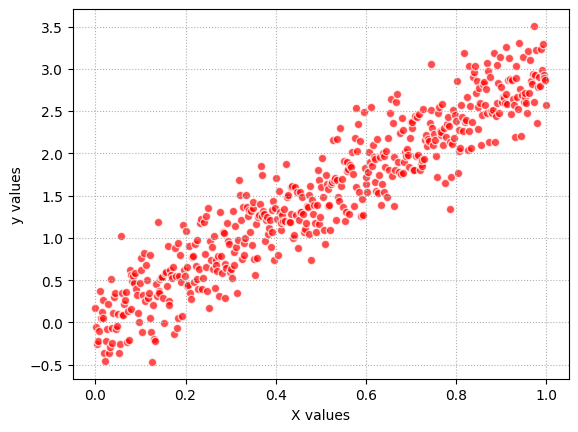

In [4]:
fig, ax = plt.subplots()
ax.scatter(X, y, c='red', edgecolor='w', alpha=0.7)
ax.grid(True, linestyle=':')
ax.set_xlabel('X values')
ax.set_ylabel('y values')
plt.show()

In [5]:
def mae(y: Array, y_hat: Array) -> float:
    return np.mean(np.abs(y - y_hat))

def mse(y: Array, y_hat: Array) -> float:
    return np.mean((y - y_hat) ** 2)

def rmse(y: Array, y_hat: Array) -> float:
    return np.sqrt(mse(y, y_hat))

In [6]:
def plot_fn(X, y, y_hat):
    fig, ax = plt.subplots()
    ax.scatter(X, y, c='#FF4500', edgecolor='w', alpha=0.7)
    ax.plot(X, y_hat, c='#1E90FF', linewidth=3)
    ax.grid(True, linestyle=':')
    ax.set_xlabel('X values')
    ax.set_ylabel('y values')
    plt.close(fig)
    return fig
    # plt.show()

In [166]:
class LinearRegression(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        beta: float | None = None,
        alpha: float | None = None
    ) -> None:
        self.beta = np.random.normal(0, 0.1) if beta is None else beta
        self.alpha = np.random.normal(0, 0.1) if alpha is None else alpha
        self.history: list[AxesImage] = []

    
    def fit(self, X: Array, y: Array) -> 'LinearRegression':
        for epoch in range(5_000):
            if epoch % 100 == 0:
                self.history.append((self.alpha, self.beta))
            self._backpropagation(X, y)
            
        return self

    def predict(self, X: Array) -> Array:
        return self.alpha * X + self.beta

    def _backpropagation(
        self,
        X: Array,
        y: Array,
        lr: float = 0.01
    ) -> None:
        y_hat = self.alpha * X + self.beta
        error = y - y_hat
        grad_alpha = -2 * np.mean(error * X)
        grad_beta = -2 * np.mean(error)

        self.alpha -= lr * grad_alpha
        self.beta -= lr * grad_beta
        return None

    def plot_model_learning(self, X, y) -> AxesImage:
        fig, ax = plt.subplots()
        ax.scatter(X, y, c='#FF4500', edgecolor='w', alpha=0.7, label='True')
        line, = ax.plot([], [], c='#1E90FF', linewidth=3, label='Predict')
        ax.legend()
        
        def _init():
            line.set_data([], [])
            return line,

        def _update(frame):
            alpha, beta = self.history[frame]
            y_fit = alpha * X + beta
            line.set_data(X, y_fit)
            return line,

        ani = FuncAnimation(
            fig, 
            _update,
            frames=len(self.history),
            init_func=_init,
            blit=True,
            interval=200
        )
        plt.close(fig)
        
        return HTML(ani.to_jshtml())

In [167]:
model = LinearRegression()

In [168]:
model.alpha

-0.05182260660590041

In [169]:
model.beta

-0.035854177826766837

In [170]:
y_hat = model.predict(X)

In [171]:
rmse(y, y_hat)

np.float64(1.8134197552045757)

In [172]:
mse(y, y_hat)

np.float64(3.288491208566223)

In [173]:
mae(y, y_hat)

np.float64(1.57284092517931)

In [174]:
model.fit(X, y)

LinearRegression(alpha=np.float64(2.9827080189282382),
                 beta=np.float64(0.0029820581101724325))

In [175]:
y_hat = model.predict(X)

In [176]:
mae(y, y_hat)

np.float64(0.24538859869382207)

In [177]:
rmse(y, y_hat)

np.float64(0.3087638978417394)

In [178]:
mse(y, y_hat)

np.float64(0.0953351446104241)

In [179]:
model.plot_model_learning(X, y)

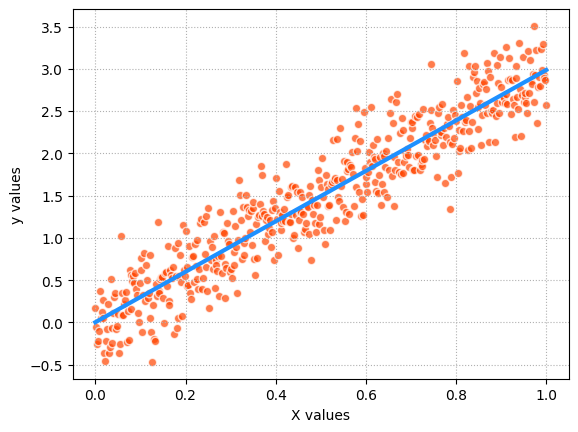

In [180]:
fig, ax = plt.subplots()
ax.scatter(X, y, c='#FF4500', edgecolor='w', alpha=0.7)
ax.plot(X, y_hat, c='#1E90FF', linewidth=3)
ax.grid(True, linestyle=':')
ax.set_xlabel('X values')
ax.set_ylabel('y values')
plt.show()

In [181]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression()

In [182]:
linear.fit(X.reshape(-1, 1), y)

LinearRegression()

In [183]:
y_hat = linear.predict(X.reshape(-1, 1))

In [184]:
linear.coef_, linear.intercept_

(array([2.9858847]), np.float64(0.0012814776631582259))

In [185]:
model.alpha, model.beta

(np.float64(2.9827080189282382), np.float64(0.0029820581101724325))